## Libraries

In [5]:
from utils.data_loader import load_cifar10
from utils.plots import plot_sample_images, plot_training_history, CIFAR10_CLASSES
from utils.models import build_mlp_cifar
import tensorflow as tf

## Loading dataset

In [3]:
(X_train_mlp_cifar10, y_train_mlp_cifar10), (X_test_mlp_cifar10, y_test_mlp_cifar10) = load_cifar10(flatten=True)
print(f"X_train: {X_train_mlp_cifar10.shape}, y_train: {y_train_mlp_cifar10.shape}")
print(f"X_test: {X_test_mlp_cifar10.shape}, y_test: {y_test_mlp_cifar10.shape}")

X_train: (50000, 3072), y_train: (50000, 10)
X_test: (10000, 3072), y_test: (10000, 10)


## Show MNIST dataset images 

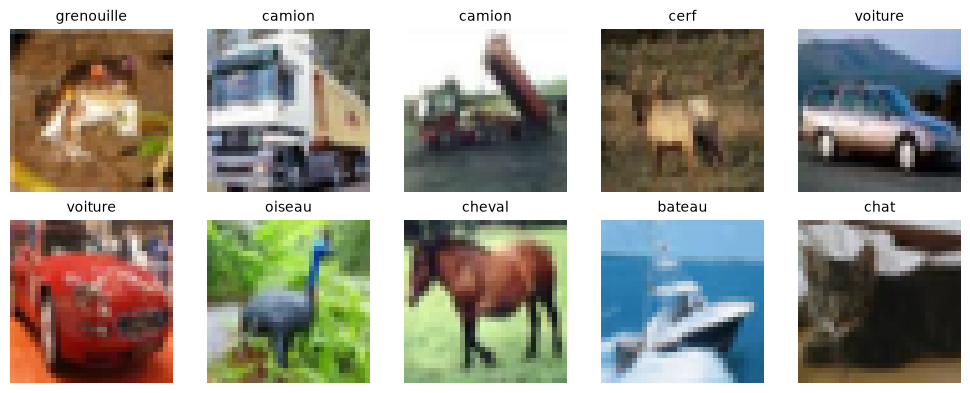

In [4]:
plot_sample_images(X_train_mlp_cifar10[:10], y_train_mlp_cifar10[:10],CIFAR10_CLASSES)


## Model implementation and training

In [6]:
mlp_cifar_model = build_mlp_cifar(learning_rate=0.0005)
mlp_cifar_model.summary()

E0000 00:00:1791488480.248629   51672 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,742,474 (6.65 MB)

 Trainable params: 1,740,682 (6.64 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [7]:

# 2. Callbacks pour éviter le surapprentissage
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=6, 
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5, 
        patience=2, 
        min_lr=1e-5
    )
]

#Entraînement
history_mlp_cifar = mlp_cifar_model.fit(
    X_train_mlp_cifar10, 
    y_train_mlp_cifar10,
    validation_data=(X_test_mlp_cifar10, y_test_mlp_cifar10),
    epochs=35,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/35
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 30ms/step - accuracy: 0.3484 - loss: 1.8321 - val_accuracy: 0.3730 - val_loss: 1.7295 - learning_rate: 5.0000e-04
Epoch 2/35
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.4238 - loss: 1.6087 - val_accuracy: 0.4232 - val_loss: 1.6223 - learning_rate: 5.0000e-04
Epoch 3/35
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.4570 - loss: 1.5169 - val_accuracy: 0.4378 - val_loss: 1.5517 - learning_rate: 5.0000e-04
Epoch 4/35
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.4795 - loss: 1.4580 - val_accuracy: 0.4119 - val_loss: 1.6360 - learning_rate: 5.0000e-04
Epoch 5/35
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.4957 - loss: 1.4145 - val_accuracy: 0.4107 - val_loss: 1.6469 - learning_rate: 5.0000e-04
Epoch 6/35
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.5251 - loss: 1.3401 - val_accuracy: 0.4923 - val_loss: 1.4424 - learning_rate: 2.5000e-04
Epoch 7/35
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/ste

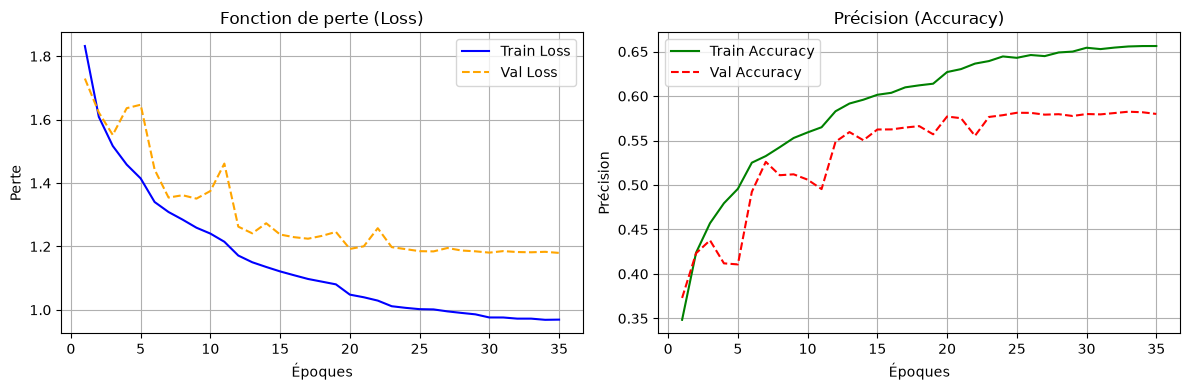

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5799 - loss: 1.1795
Précision test CIFAR-10 (MLP) : 57.99%


In [8]:
plot_training_history(history_mlp_cifar)

test_loss, test_acc = mlp_cifar_model.evaluate(X_test_mlp_cifar10, y_test_mlp_cifar10)
print(f"Précision test CIFAR-10 (MLP) : {test_acc * 100:.2f}%")